Импорт библиотек: Импортируем необходимые библиотеки:

pandas для работы с данными.

scipy.stats для проведения ANOVA (односторонней).

statsmodels.formula.api и statsmodels.stats.anova_lm для более гибкого проведения ANOVA и получения более подробной таблицы.

statsmodels.stats.multicomp.pairwise_tukeyhsd для проведения
post-hoc тестов (Tukey’s HSD).

In [7]:
import pandas as pd
import scipy.stats as stats
import statsmodels.formula.api as sm
import statsmodels.api as sa  # Import statsmodels.api separately
from statsmodels.stats.multicomp import pairwise_tukeyhsd

Создается DataFrame с примером данных об урожайности для каждой группы удобрений.

Важно: замените этот пример своими реальными данными.



In [2]:
# Создадим пример данных (замените это вашими реальными данными)
data = {'Удобрение': ['A'] * 10 + ['B'] * 10 + ['C'] * 10 + ['D'] * 10,
        'Урожайность': [3.2, 3.5, 3.1, 3.8, 3.4, 3.0, 3.3, 3.6, 3.7, 3.2,
                       4.1, 4.3, 4.0, 4.5, 4.2, 4.4, 4.6, 4.3, 4.2, 4.1,
                       2.5, 2.8, 2.6, 2.9, 2.7, 2.4, 2.3, 2.6, 2.5, 2.7,
                       1.8, 2.0, 1.9, 2.2, 2.1, 1.7, 1.6, 1.9, 1.8, 2.0]}
df = pd.DataFrame(data)


Функция stats.f_oneway() выполняет односторонний ANOVA.

В функцию передаются отдельные массивы данных для каждой группы.

Возвращает F-статистику и p-значение.

In [3]:
# 1. Проведение ANOVA (с использованием scipy.stats)
fvalue, pvalue = stats.f_oneway(df['Урожайность'][df['Удобрение'] == 'A'],
                                df['Урожайность'][df['Удобрение'] == 'B'],
                                df['Урожайность'][df['Удобрение'] == 'C'],
                                df['Урожайность'][df['Удобрение'] == 'D'])
print("Результаты ANOVA (scipy.stats):")
print(f"F-статистика: {fvalue}, p-значение: {pvalue}")

Результаты ANOVA (scipy.stats):
F-статистика: 240.59152215799523, p-значение: 7.256033610535613e-24


sm.ols('Урожайность ~ Удобрение', data=df).fit() создает модель линейной регрессии, где Урожайность - зависимая переменная, а Удобрение - независимая переменная.

sm.stats.anova_lm(model, typ=2) создает таблицу ANOVA.

typ=2 задает тип суммы квадратов, который обычно используется в ANOVA.

Этот подход более гибкий и позволяет анализировать более сложные модели.

In [8]:
# 2. Проведение ANOVA (с использованием statsmodels) - более гибкий подход
model = sm.ols('Урожайность ~ Удобрение', data=df).fit()
anova_table = sa.stats.anova_lm(model, typ=2)  # Use statsmodels.api
print("\nРезультаты ANOVA (statsmodels):")
print(anova_table)


Результаты ANOVA (statsmodels):
             sum_sq    df           F        PR(>F)
Удобрение  31.21675   3.0  240.591522  7.256034e-24
Residual    1.55700  36.0         NaN           NaN


Если p-значение из ANOVA меньше заданного уровня значимости (обычно 0.05), это означает, что есть статистически значимые различия между средними значениями групп.

Однако ANOVA не говорит, какие конкретно группы отличаются друг от друга. Для этого используются post-hoc тесты.

Tukey’s HSD (Honestly Significant Difference) - один из самых популярных post-hoc тестов. Он сравнивает все возможные пары групп и определяет, какие пары имеют статистически значимые различия.

pairwise_tukeyhsd(endog=df['Урожайность'], groups=df['Удобрение'], alpha=0.05) выполняет тест Tukey’s HSD.
* endog - зависимая переменная.

* groups - независимая переменная (группы).
* alpha - уровень значимости.

Результаты Tukey’s HSD показывают разницу между средними значениями каждой пары групп, доверительный интервал для этой разницы и p-значение.

 Если p-значение меньше уровня значимости, то разница между группами считается статистически значимой.

In [9]:
# 3. Post-hoc тесты (если ANOVA показала значимый результат) - Tukey's HSD
if pvalue < 0.05:  # Если p-значение из ANOVA меньше 0.05, проводим post-hoc тесты
    m_comp = pairwise_tukeyhsd(endog=df['Урожайность'], groups=df['Удобрение'], alpha=0.05)
    print("\nPost-hoc тесты (Tukey's HSD):")
    print(m_comp)
    # m_comp.summary() # Может быть использован вместо print(m_comp) для более простого вывода




Post-hoc тесты (Tukey's HSD):
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     A      B     0.89   0.0  0.6395  1.1405   True
     A      C    -0.78   0.0 -1.0305 -0.5295   True
     A      D    -1.48   0.0 -1.7305 -1.2295   True
     B      C    -1.67   0.0 -1.9205 -1.4195   True
     B      D    -2.37   0.0 -2.6205 -2.1195   True
     C      D     -0.7   0.0 -0.9505 -0.4495   True
---------------------------------------------------


In [10]:
# Интерпретация результатов
print("\nИнтерпретация:")
if pvalue < 0.05:
    print("ANOVA показала статистически значимые различия между средними значениями урожайности для разных удобрений.")
    print("Post-hoc тесты (Tukey's HSD) показывают, какие конкретно группы отличаются друг от друга.")
    # Посмотрите на результаты Tukey's HSD чтобы понять, какие пары удобрений имеют значимые различия.
else:
    print("ANOVA не показала статистически значимых различий между средними значениями урожайности для разных удобрений.")


Интерпретация:
ANOVA показала статистически значимые различия между средними значениями урожайности для разных удобрений.
Post-hoc тесты (Tukey's HSD) показывают, какие конкретно группы отличаются друг от друга.


Интерпретация результатов:

Сначала смотрите на p-значение из ANOVA. Если оно меньше 0.05, то есть значимые различия между группами.

Затем смотрите на результаты post-hoc тестов (Tukey’s HSD), чтобы узнать, какие конкретно группы отличаются друг от друга.

Вывод результатов TukeyHSD

Результат pairwise_tukeyhsd выглядит примерно так:

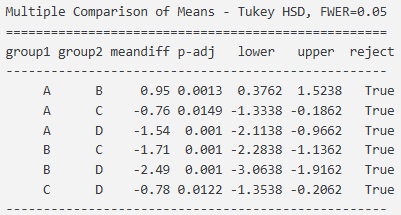

**group1, group2:** Пары групп, которые сравниваются.

**meandiff:** Разница между средними значениями этих двух групп.

**p-adj:** P-значение, скорректированное для множественного сравнения.

**lower, upper:** Нижняя и верхняя границы доверительного интервала для разницы между средними.

**reject**: True, если разница между группами статистически значима (p-adj < 0.05), False в противном случае.

Предположения ANOVA:

Перед проведением ANOVA важно проверить, выполнены ли следующие предположения:

Нормальность: Данные в каждой группе должны быть нормально распределены. Можно проверить с помощью теста Шапиро-Уилка или визуально с помощью гистограмм и Q-Q графиков.
Однородность дисперсий (Homogeneity of variances): Дисперсии в каждой группе должны быть примерно одинаковыми. Можно проверить с помощью теста Левена или теста Бартлетта.

Независимость: Наблюдения должны быть независимыми друг от друга.

Если предположения ANOVA не выполнены, то можно использовать альтернативные методы, такие как тест Крускала-Уоллиса (Kruskal-Wallis test), который является непараметрическим аналогом ANOVA.


Альтернативы ANOVA (если не соблюдаются предположения):


Крускала-Уоллиса (Kruskal-Wallis test): Непараметрический тест, который не требует нормальности данных. Он проверяет, являются ли медианы нескольких групп одинаковыми.

Преобразование данных: Иногда можно преобразовать данные (например, взять логарифм), чтобы они соответствовали предположениям ANOVA.

Welch’s ANOVA: Вариант ANOVA, который не требует однородности дисперсий.

Важно: ANOVA показывает, есть ли какие-либо статистически значимые различия между группами. Чтобы узнать, какие именно группы отличаются друг от друга, необходимы post-hoc тесты.